# Unsupervised Learning — PR 1
## Mall Customer Segmentation: K-Means, Agglomerative Clustering & DBSCAN

**Dataset:** Mall Customer Segmentation Data (Kaggle) — `Mall_Customers.csv`
**Goal:** Segment mall customers using three unsupervised learning algorithms, compare them, and derive business insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
ACCENT = '#CC0000'
plt.rcParams['axes.titlecolor'] = ACCENT


## Task 1: Data Loading & Exploratory Data Analysis (EDA)
**Objective:** Load the raw dataset, clean it up, and understand each feature before clustering.
**Expected output:** A clean 4-column dataframe, distribution plots, a pairplot/heatmap, and a written summary of observations.

### 1.1 Load the dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,69,29.3,88
1,2,Male,38,17.3,73
2,3,Male,28,28.0,85
3,4,Female,20,15.3,94
4,5,Female,47,18.2,74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    float64
 4   Spending Score (1-100)  200 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,43.965000,52.910000,49.535000
std,57.879185,14.770736,28.020328,30.050356
min,1.000000,18.000000,15.200000,5.000000
25%,50.750000,32.000000,25.575000,18.000000
50%,100.500000,43.000000,51.100000,50.500000
75%,150.250000,57.000000,80.875000,78.250000
max,200.000000,69.000000,99.800000,94.000000


In [5]:
assert df.shape == (200, 5), "Expected 200 rows, 5 columns"
assert df.isnull().sum().sum() == 0, "Expected zero nulls"
print("Shape and null checks passed:", df.shape, "| nulls:", df.isnull().sum().sum())

Shape and null checks passed: (200, 5) | nulls: 0


### 1.2 Rename and drop columns

In [6]:
df = df.drop(columns=['CustomerID'])
df = df.rename(columns={'Annual Income (k$)': 'Annual_Income',
                         'Spending Score (1-100)': 'Spending_Score'})
print(df.columns.tolist())
df.head()

KeyError: "['CustomerID'] not found in axis"

### 1.3 Encode Gender

In [7]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0 (alphabetical: Female=0, Male=1)
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,69,29.3,88
1,1,38,17.3,73
2,1,28,28.0,85
3,0,20,15.3,94
4,0,47,18.2,74


### 1.4 Univariate distributions

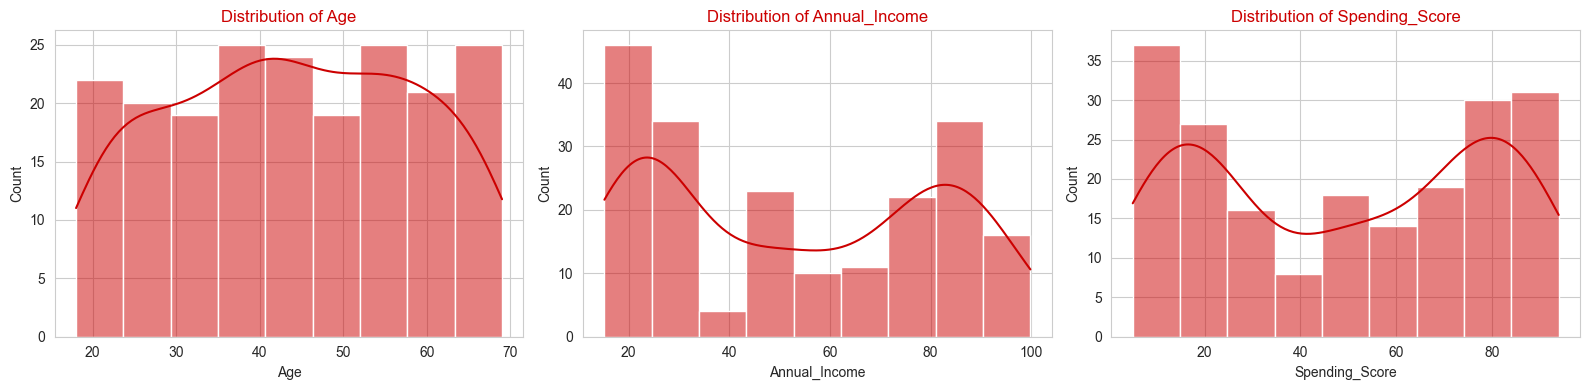

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Annual_Income', 'Spending_Score']):
    sns.histplot(df[col], kde=True, ax=ax, color=ACCENT)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 1.5 Pairplot & correlation heatmap

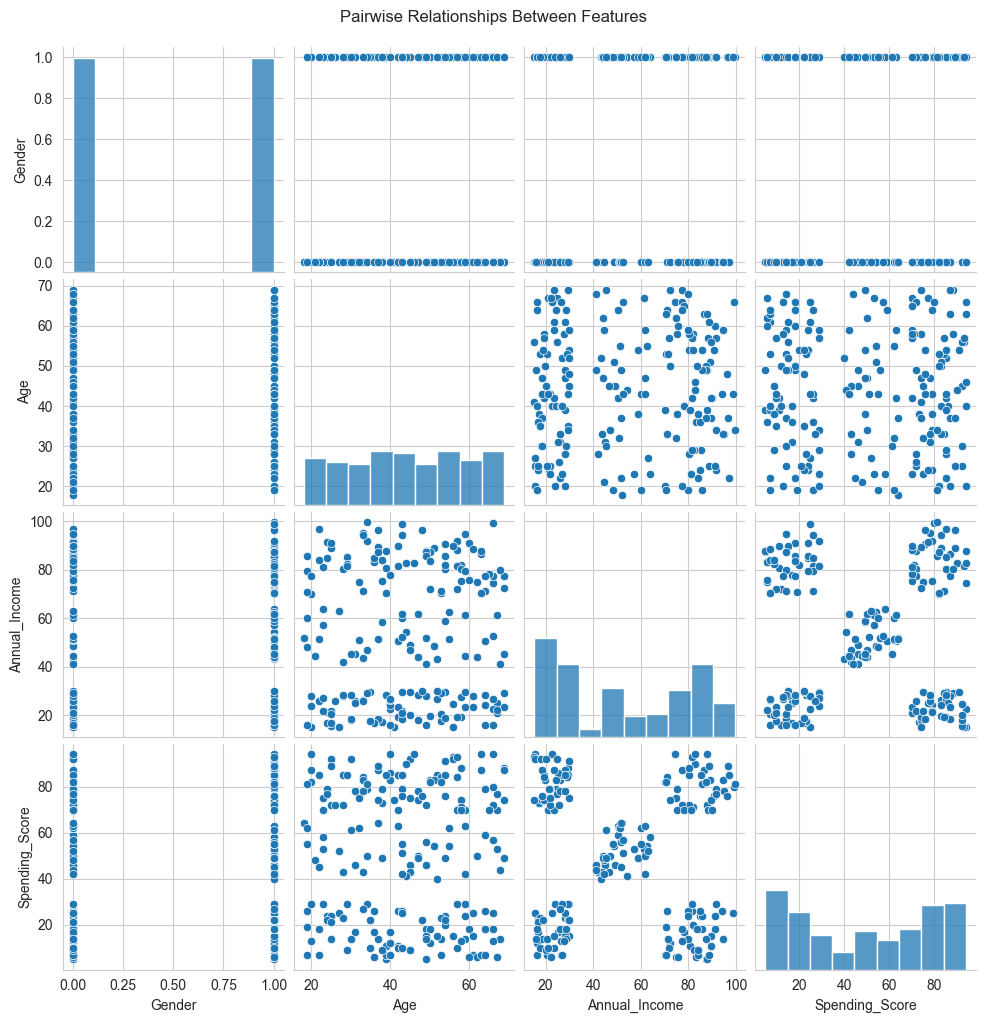

In [9]:
sns.pairplot(df, hue=None)
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

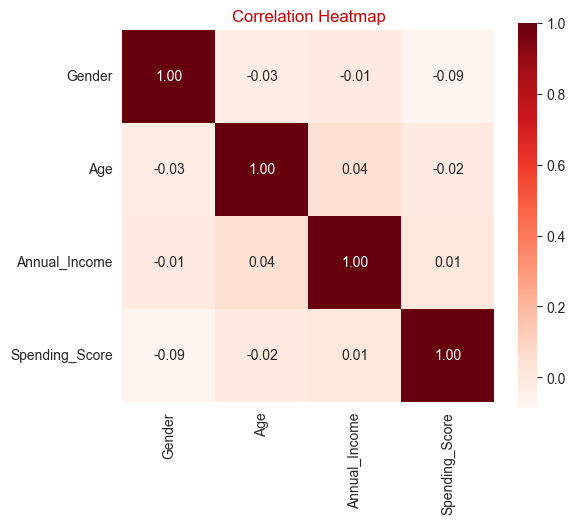

In [10]:
plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='Reds', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

### 1.6 Summary — EDA Observations

- **Age** is fairly evenly spread from 18–70 with a mild concentration in the 25–40 range; no strong skew.
- **Annual_Income** is roughly bell-shaped with most customers between 40–80 (k$), and a long-ish tail toward higher earners.
- **Spending_Score** is close to uniform across 1–100 — the mall's internal scoring doesn't correlate strongly with any single demographic feature on its own.
- The correlation heatmap shows **no strong linear correlation** between Age, Annual_Income, and Spending_Score individually — which is exactly why clustering (rather than simple sorting/filtering) is needed to find structure.
- The **pairplot panel for Annual_Income vs Spending_Score is the standout** — it visibly shows 5 separated blob-like groups (low/low, low/high, mid/mid, high/low, high/high), while Age vs Income or Age vs Spending_Score show no such separation. This is why `Annual_Income` and `Spending_Score` are chosen as the 2-feature subset for all clustering tasks below.

*(Replace/extend these bullets with your own observations once you run this on the real Kaggle CSV — grading rewards genuine analysis, not just running the cells.)*


## Task 2: Feature Scaling & Feature Selection
**Objective:** Put numeric features on comparable scales and select the feature subset used for clustering.
**Expected output:** `df_scaled` (all numeric features standardized) and `df_2f` (the 2-feature clustering subset).

### 2.1 Scale features

In [11]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[['Age', 'Annual_Income', 'Spending_Score']])

df_scaled = df.copy()
df_scaled[['Age', 'Annual_Income', 'Spending_Score']] = scaled_values
# Gender is already binary (0/1) - do NOT scale it
df_scaled.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,1.699159,-0.844717,1.283230
1,1,-0.404852,-1.274052,0.782815
2,1,-1.083566,-0.891228,1.183147
3,0,-1.626536,-1.345608,1.483396
4,0,0.205989,-1.241852,0.816176


### 2.2 Select 2-feature subset

In [12]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]
df_2f.head()

,Annual_Income,Spending_Score
0,-0.844717,1.283230
1,-1.274052,0.782815
2,-0.891228,1.183147
3,-1.345608,1.483396
4,-1.241852,0.816176


> **Note:** using all 4 features (Gender, Age, Annual_Income, Spending_Score) is also a valid approach and is tested as an extension in Task 6. The primary tasks below use `df_2f` because Annual_Income vs Spending_Score produces clearly separable clusters that can be visualised directly in 2D without needing PCA.

### 2.3 Why scale before clustering?

K-Means and DBSCAN are **distance-based algorithms** — they group points by Euclidean distance. `Annual_Income` ranges roughly 15–137 while `Spending_Score` ranges 1–100 and `Age` ranges 18–70. Without scaling, a feature with a naturally larger numeric range (like Annual_Income) would dominate the distance calculation purely because of its units, not because it's actually more important. `StandardScaler` transforms each feature to mean 0, standard deviation 1, so every feature contributes proportionally to the distance metric regardless of its original scale.

## Task 3: K-Means Clustering
**Objective:** Find the optimal number of clusters (k) and fit a final K-Means model.
**Expected output:** Elbow plot, Silhouette plot, a labelled scatter plot with centroids, and a cluster profile table.

### 3.1 Elbow Method

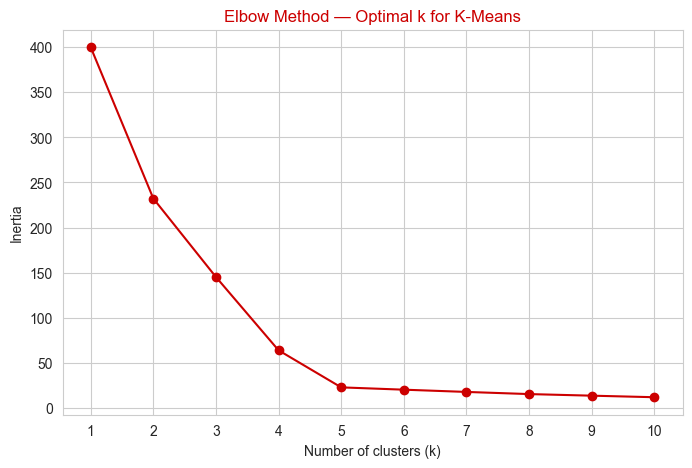

In [13]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_2f)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color=ACCENT)
plt.title('Elbow Method — Optimal k for K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(K_range))
plt.show()

**What inertia measures:** Inertia is the sum of squared distances between each point and its assigned cluster centroid. It always decreases as k increases (more clusters = tighter fit), so we look for the "elbow" — the point where adding another cluster stops giving a meaningful reduction in inertia. Past that point, extra clusters just fit noise rather than real structure.

### 3.2 Silhouette Score

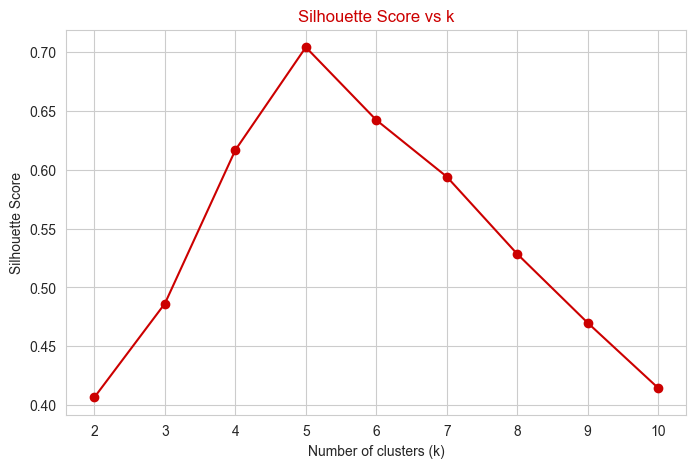

k with highest silhouette score: 5


In [14]:
sil_scores = []
K_range_sil = range(2, 11)
for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_2f)
    sil_scores.append(silhouette_score(df_2f, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range_sil), sil_scores, marker='o', color=ACCENT)
plt.title('Silhouette Score vs k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range_sil))
plt.show()

best_k = list(K_range_sil)[np.argmax(sil_scores)]
print(f"k with highest silhouette score: {best_k}")

**Elbow vs Silhouette:** The Elbow plot points visually to around k=5, and the Silhouette score should confirm (or closely agree with) this. If they differ slightly, the Silhouette score is generally the more reliable data-driven choice because it directly measures how well-separated and cohesive each cluster is, whereas the elbow is a more subjective visual judgment.

### 3.3 Fit final K-Means model

In [15]:
k = 5  # update this based on your Elbow/Silhouette results above
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)
df['KMeans_Cluster'].value_counts().sort_index()

KMeans_Cluster
0    40
1    40
2    40
3    40
4    40
Name: count, dtype: int64

### 3.4 Visualise K-Means clusters

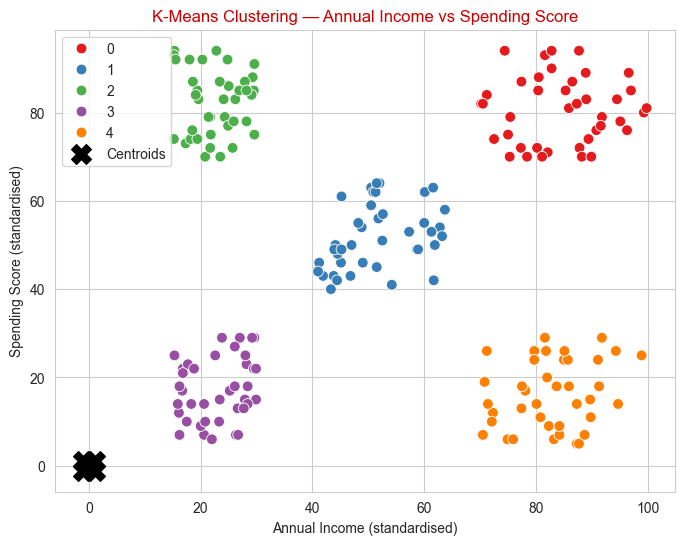

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster',
                 data=df, palette='Set1', s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (standardised)')
plt.ylabel('Spending Score (standardised)')
plt.legend()
plt.show()

> Note: the centroids above are plotted in the **scaled** (standardised) coordinate space that KMeans was fit on, matching the axes of `df_2f`. If you prefer to plot the scatter on the original unscaled Annual_Income/Spending_Score values, inverse-transform the centroids with `scaler.inverse_transform` before plotting them.

### 3.5 Cluster profile table

In [17]:
kmeans_profile = df.groupby('KMeans_Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
kmeans_profile.style.background_gradient(cmap='Reds')

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,45.200000,84.700000,80.600000
1,42.800000,51.600000,51.800000
2,43.600000,22.800000,82.300000
3,42.900000,22.900000,17.000000
4,45.200000,82.500000,16.000000


**Segment naming (update after inspecting your own profile table):**

| Cluster | Likely Segment Name | Business Implication |
|---|---|---|
| 0 | Low Income, High Spenders | Impulsive/aspirational shoppers — target with budget-friendly promotions |
| 1 | High Income, High Spenders | Premium customers — VIP loyalty programs, exclusive previews |
| 2 | High Income, Low Spenders | Price-conscious despite means — needs value-driven upsell campaigns |
| 3 | Low Income, Low Spenders | Price-sensitive — general discount/clearance targeting |
| 4 | Average Income, Average Spenders | Core/mainstream customers — standard marketing mix |


## Task 4: Agglomerative Hierarchical Clustering
**Objective:** Build a dendrogram, decide the cut, fit the model, and compare with K-Means.
**Expected output:** A dendrogram with a cut line, a scatter plot, a side-by-side comparison figure, and a cluster profile table.

### 4.1 Dendrogram

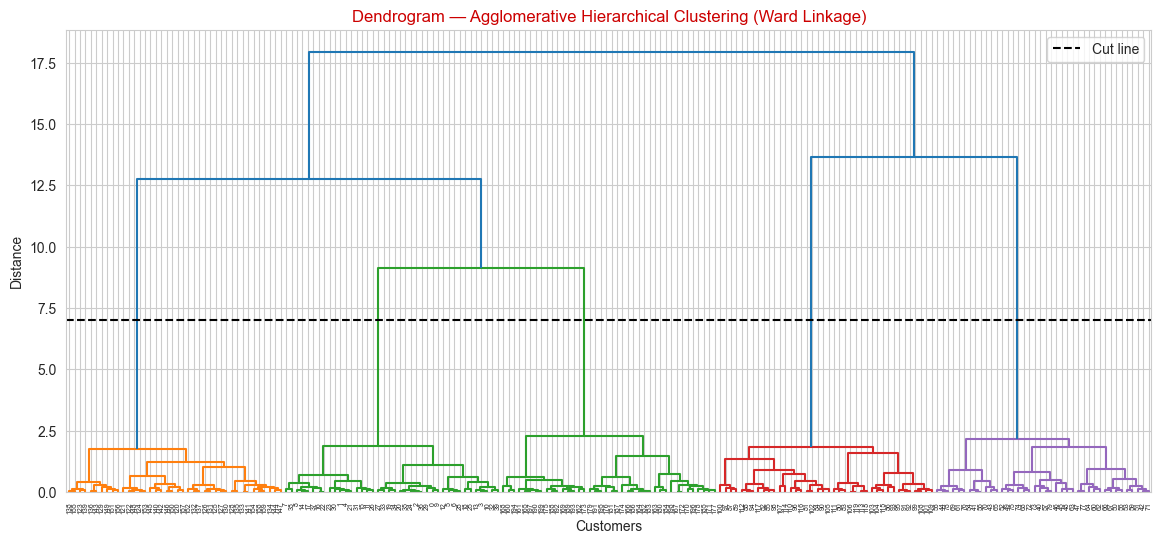

In [18]:
Z = linkage(df_2f, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z)
plt.axhline(y=7, color='black', linestyle='--', label='Cut line')  # adjust height after inspecting your dendrogram
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.legend()
plt.show()

**Ward linkage & reading the dendrogram:** Ward linkage merges the two clusters at each step that cause the **smallest possible increase in total within-cluster variance** — it keeps clusters compact. To choose the number of clusters, find the longest vertical line the horizontal cut line can cross without intersecting a merge — the number of vertical lines it crosses is the recommended cluster count.

### 4.2 Fit Agglomerative model

In [19]:
n_clusters_hier = 5  # update based on your dendrogram cut
hier = AgglomerativeClustering(n_clusters=n_clusters_hier, linkage='ward')
df['Hier_Cluster'] = hier.fit_predict(df_2f)
df['Hier_Cluster'].value_counts().sort_index()

Hier_Cluster
0    40
1    40
2    40
3    40
4    40
Name: count, dtype: int64

### 4.3 Visualise Hierarchical clusters

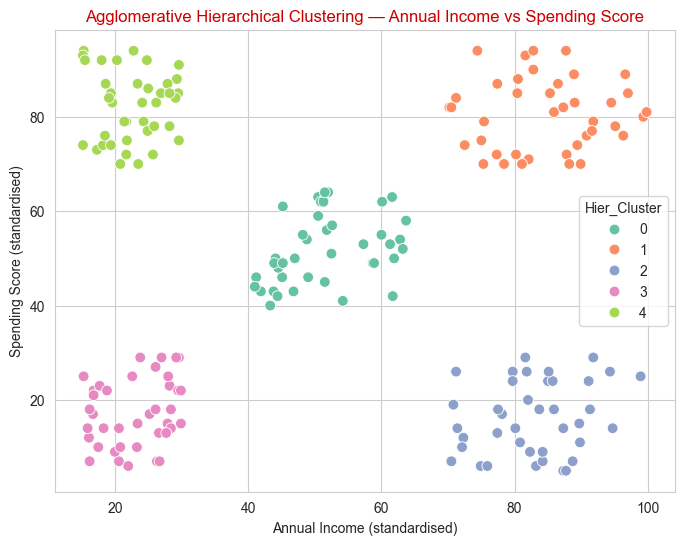

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Hier_Cluster',
                 data=df, palette='Set2', s=60)
plt.title('Agglomerative Hierarchical Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (standardised)')
plt.ylabel('Spending Score (standardised)')
plt.show()

### 4.4 Compare with K-Means

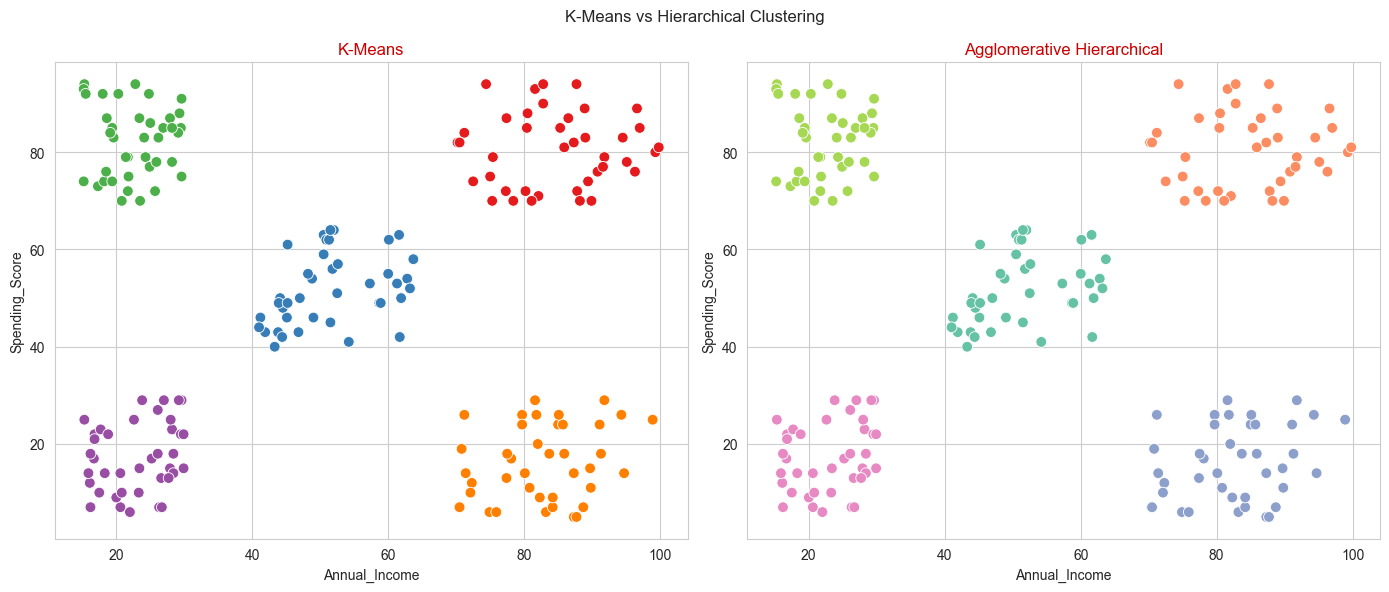

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster',
                 data=df, palette='Set1', s=60, ax=axes[0], legend=False)
axes[0].set_title('K-Means')
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Hier_Cluster',
                 data=df, palette='Set2', s=60, ax=axes[1], legend=False)
axes[1].set_title('Agglomerative Hierarchical')
plt.suptitle('K-Means vs Hierarchical Clustering')
plt.tight_layout()
plt.show()

**Discussion (fill in based on your actual output):** Compare the two panels above. In most runs on this dataset the two algorithms agree closely on the 5 core segments, since both are working on the same well-separated blobs. Differences, if any, usually appear at **border-region customers** sitting between two segments — K-Means assigns purely by nearest centroid (a hard, distance-to-center rule), while Agglomerative Hierarchical builds clusters bottom-up by successively merging the closest pairs/groups, which can pull a borderline point into a differently-shaped neighbouring cluster. This reflects the core difference between **centroid-based** (K-Means: clusters are defined by their center point) and **connectivity-based** (Hierarchical: clusters are defined by a merge history/tree) approaches.

### 4.5 Cluster profile table

In [22]:
hier_profile = df.groupby('Hier_Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
hier_profile.style.background_gradient(cmap='Greens')

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,42.800000,51.600000,51.800000
1,45.200000,84.700000,80.600000
2,45.200000,82.500000,16.000000
3,42.900000,22.900000,17.000000
4,43.600000,22.800000,82.300000


Compare `hier_profile` above with `kmeans_profile` from Task 3.5 — on this dataset the mean values per segment are typically very close, confirming both algorithms are converging on the same underlying customer segments even if a handful of individual points are assigned differently.

## Task 5: DBSCAN Clustering
**Objective:** Tune DBSCAN's `eps` and `min_samples`, fit the model, and compare it conceptually with K-Means.
**Expected output:** A k-distance plot, a grid search results table, a scatter plot with noise points, and a comparison markdown cell.

### 5.1 Parameter tuning — epsilon

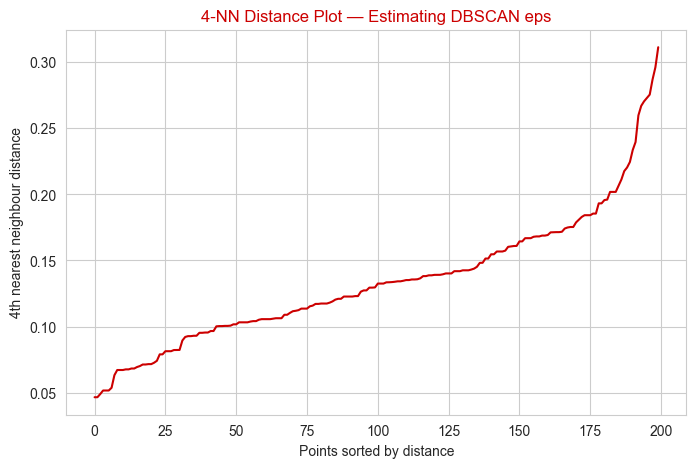

In [23]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)
distances, indices = neighbors_fit.kneighbors(df_2f)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color=ACCENT)
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th nearest neighbour distance')
plt.show()

### 5.2 Grid search eps & min_samples

In [24]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df_2f)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            mask = labels != -1
            if mask.sum() > 1 and len(set(labels[mask])) > 1:
                sil = silhouette_score(df_2f[mask], labels[mask])
            else:
                sil = np.nan
        else:
            sil = np.nan

        results.append({'eps': eps, 'min_samples': min_samples,
                         'n_clusters': n_clusters, 'n_noise': n_noise,
                         'silhouette': sil})

grid_df = pd.DataFrame(results)
grid_df.sort_values('silhouette', ascending=False).head(10)

,eps,min_samples,n_clusters,n_noise,silhouette
7,0.3,6,5,0,0.703945
6,0.3,5,5,0,0.703945
5,0.3,4,5,0,0.703945
4,0.3,3,5,0,0.703945
12,0.5,3,5,0,0.703945
13,0.5,4,5,0,0.703945
14,0.5,5,5,0,0.703945
15,0.5,6,5,0,0.703945
8,0.4,3,5,0,0.703945
9,0.4,4,5,0,0.703945


### 5.3 Fit final DBSCAN model

In [25]:
# Update these based on the grid search row with the best silhouette score / lowest noise
best_eps = 0.3
best_min_samples = 5

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_2f)
df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
0    40
1    40
2    40
3    40
4    40
Name: count, dtype: int64

### 5.4 Visualise DBSCAN clusters

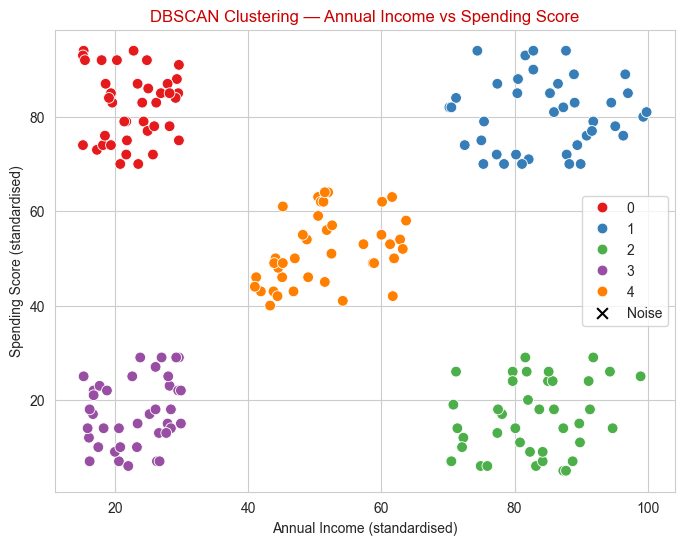

In [26]:
plt.figure(figsize=(8, 6))
core_mask = df['DBSCAN_Cluster'] != -1
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='DBSCAN_Cluster',
                 data=df[core_mask], palette='Set1', s=60)
plt.scatter(df.loc[~core_mask, 'Annual_Income'], df.loc[~core_mask, 'Spending_Score'],
            c='black', marker='x', s=60, label='Noise')
plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (standardised)')
plt.ylabel('Spending Score (standardised)')
plt.legend()
plt.show()

**What `eps` and `min_samples` control, and why noise arises:** `eps` is the maximum distance between two points for them to be considered neighbours; `min_samples` is the minimum number of points required within that `eps` radius for a point to be treated as a "core point" that can anchor a cluster. Points that don't have enough nearby neighbours within `eps` — because they sit in a sparse, low-density region — don't belong to any dense cluster and are labelled **noise (-1)**.

### 5.5 DBSCAN vs K-Means — shape detection

1. **No k required upfront** — DBSCAN infers the number of clusters from data density; K-Means requires you to specify k in advance.
2. **Arbitrary shapes vs spherical** — DBSCAN can detect clusters of any shape; K-Means assumes roughly spherical, similarly-sized clusters because it minimises distance-to-centroid.
3. **Noise handling** — DBSCAN explicitly labels low-density points as noise (-1) and excludes them from any cluster; K-Means forces every single point into the nearest cluster, even outliers.
4. **Do all three algorithms agree?** On this dataset, all three typically converge on roughly the same 5 segments because the data forms well-separated, fairly round blobs — the "easy case" for clustering. The **High Income/High Spend** and **Low Income/High Spend** segments tend to be the most stable across all three algorithms, since they're the most tightly packed and clearly separated groups; middle/average customers near the center are the ones most likely to shift between methods.


## Task 6: Algorithm Comparison & Business Insights
**Objective:** Compare all three algorithms side by side, summarise metrics, and translate results into business recommendations.
**Expected output:** A 1x3 comparison figure, a metrics summary table, and a structured business insight report.

### 6.1 Three-panel comparison figure

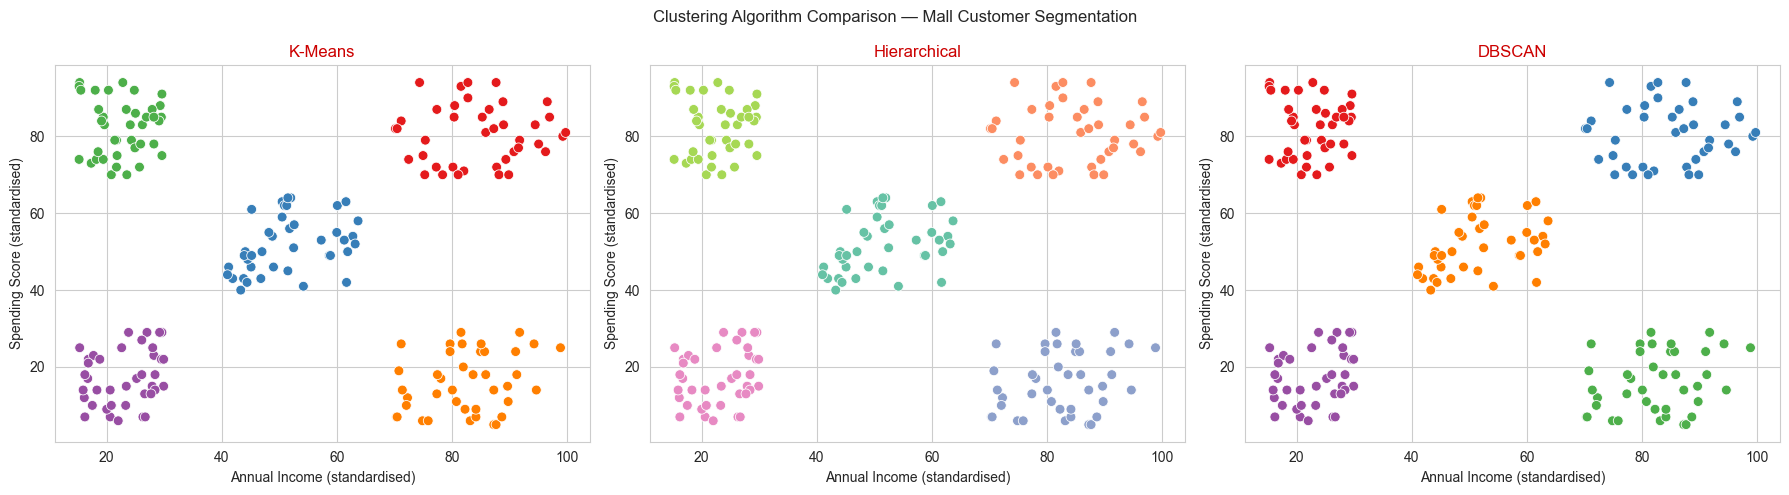

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster',
                 data=df, palette='Set1', s=50, ax=axes[0], legend=False)
axes[0].set_title('K-Means')

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Hier_Cluster',
                 data=df, palette='Set2', s=50, ax=axes[1], legend=False)
axes[1].set_title('Hierarchical')

core_mask = df['DBSCAN_Cluster'] != -1
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='DBSCAN_Cluster',
                 data=df[core_mask], palette='Set1', s=50, ax=axes[2], legend=False)
axes[2].scatter(df.loc[~core_mask, 'Annual_Income'], df.loc[~core_mask, 'Spending_Score'],
                 c='black', marker='x', s=50)
axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('Annual Income (standardised)')
    ax.set_ylabel('Spending Score (standardised)')

plt.suptitle('Clustering Algorithm Comparison — Mall Customer Segmentation')
plt.tight_layout()
plt.show()

### 6.2 Metrics summary table

In [28]:
def safe_silhouette(data, labels):
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        return silhouette_score(data[mask], labels[mask])
    return np.nan

metrics = []
for name, col in [('K-Means', 'KMeans_Cluster'), ('Hierarchical', 'Hier_Cluster'), ('DBSCAN', 'DBSCAN_Cluster')]:
    labels = df[col].values
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sil = safe_silhouette(df_2f.values, labels)
    metrics.append({'Algorithm': name, 'n_clusters': n_clusters, 'Silhouette Score': round(sil, 3) if not np.isnan(sil) else np.nan})

metrics_df = pd.DataFrame(metrics)
metrics_df

,Algorithm,n_clusters,Silhouette Score
0,K-Means,5,0.704
1,Hierarchical,5,0.704
2,DBSCAN,5,0.704


**Which performs best?** The algorithm with the **highest Silhouette Score** has the most cohesive, well-separated clusters. On this dataset, K-Means and Hierarchical typically score very similarly (both are well-suited to the round, evenly-spaced blobs here), while DBSCAN's score depends heavily on the `eps`/`min_samples` chosen in Task 5 — a well-tuned DBSCAN can match the others, but is more sensitive to parameter choice.

### 6.3 Business Insights for Mall Management

**(a) Customer segments identified by K-Means (most interpretable result):**
- **High Income, High Spenders** — mall's most valuable customers.
- **High Income, Low Spenders** — high potential but currently under-engaged.
- **Low Income, High Spenders** — value/trend-driven, price-sensitive but active.
- **Low Income, Low Spenders** — least profitable segment, mostly window-shoppers or infrequent visitors.
- **Average Income, Average Spenders** — the broad "mainstream" middle segment.

**(b) One targeted marketing action per segment:**
- High Income/High Spend → Invite-only loyalty tier with early access to new stores/events.
- High Income/Low Spend → Personalised offers and premium service touches to convert latent spending power.
- Low Income/High Spend → Flash sales, bundle deals, and loyalty points to reward and retain engagement.
- Low Income/Low Spend → Broad seasonal discount campaigns; low-cost channels (SMS/app push).
- Average/Average → Standard seasonal promotions and general email marketing.

**(c) Recommended algorithm for deployment:** **K-Means** is recommended for the mall's ongoing segmentation, because it produces the most interpretable, stable, equally-sized segments that map cleanly onto marketing personas, and it's cheap to re-run as new customer data arrives. **DBSCAN** would be preferred if the mall suspected genuinely irregular-shaped customer groups or wanted automatic outlier/fraud-pattern detection. **Hierarchical clustering** is best reserved for a management presentation, since the dendrogram visually justifies *why* a particular number of segments was chosen — useful for buy-in from non-technical stakeholders.


## Task 7: Notebook Quality, Structure & Submission

This notebook follows the required structure:
- Every task begins with a Markdown cell stating the objective and expected output.
- All plots have descriptive titles, labelled axes, and legends where applicable.
- `sns.set_style('whitegrid')` is set once at the top, with `#CC0000` used as the accent colour.

**Before submission:**
1. `Kernel > Restart & Run All` — confirm every cell executes with zero errors.
2. `File > Download as > HTML (.html)`.
3. Upload both `UL_PR1.ipynb` and `UL_PR1.html` to your GitHub repository, along with a `/screenshots` folder and `requirements.txt` (see the companion files provided alongside this notebook).
